# **Global Electricity Generation and Consumption (a Python project by Anne Aruja Gnanarajan, April 2024)**

This project will analyse global electricity generation and consumption data by country, using data from a set of 48 countries provided in the OECD dataset. The project will also look at per-person electricity production and CO2 emissions in relation to electricity production.

Summary of contents: 

1. Introduction
2. Data Inspection and Cleaning
3. Analysis and Answers to Questions
4. Findings
5. Recommendations and Conclusion
6. References


# 1. Introduction

Electricity is a necessity for most of the world today, for both households and businesses. For households, electricity is a necessity for food preparation, household heating and cooling, electronics (eg. computers, laptops, and phones), cleaning and other tasks. For businesses, electricity is crucial for manufaturing, construction, communications, banking, retail and many other industries. 

As an Electrical Engineer myself who has previously worked at the Sydney electricity distribution company, Ausgrid, I have an appreciation for how much infrastructure and planning is required to power the greater Sydney region, considering electricity generation,  efficient transmission over long distances and end-customer distribution. 

"Affordable and clean energy" is listed as Goal number 7 of the UN's "Sustainable Development Goals" (UN, 2023) as they have identified this as being crucial for the future generations of mankind.

For these reasons, the datasets I have chosen are related to electricity production and consumption, world population and CO2 emissions. 

## **Questions to be Answered**

1. Which are the top 10 countries in the OECD dataset with the highest "Final Consumption" of Electricity for the entirety of 2023?
2. Which are the top 10 countries in the OECD dataset with the highest Net Electricity Production for the entirety of 2023?
3. How has the usage of different types of Products (Coal, Hydro, Solar, etc.) in electricity production varied from 2015 to 2023? Which product  has the largest share of Electricity production? 
4. How has the share of renewables in electricity production varied from 2015 to 2023 for Australia? How does this trend look for other countries in the OECD dataset?
5. How does the electricity production relate to the population of the country for 2023?
6. Which country has the highest "per person" production for 2023?
7. How does the total electricity production vary over the course of a year in terms of yearly seasonality? 
8. How does the electricity production of Australia vary over the course of a year?
9. Which countries produced the most CO2 per capita in 2019 (latest available year)?
10. Looking a individual countries, How does the amount of combustible fuels used in electricity production relate to CO2 emissions in 2019?

## **Data Files**

**1. Electricity monthy data**
This dataset was obtained from the IEA (2024) at: https://www.iea.org/data-and-statistics/data-product/monthly-electricity-statistics. It is important to note that this data contains data for a set of 48 countries. Electricity Production data is available for all 48 of these countries, while Consumption data is only available 37 countries. (While a dataset with all 200+ countries was found, this was over 40MB and therefore too large.) Main columns include:
* Country
* Time (month and year)
* Balance (metric - eg. Net Electricity Production)
* Product (type of generation - eg. Coal, Hydro)
* Value (numerical)
* Unit (eg. Gigawatt Hours - GWh)

**2. Population data**
This dataset was been obtained from Kaggle (Arvidsson, 2023): https://www.kaggle.com/datasets/joebeachcapital/world-population-by-country-2023. It is based on the United Nations' estimates. The main columns it contains are: 
* Country
* Population2023
* Land Area (km2)

This dataset also contains additional metric columns (eg. population density, etc.) which will not be used in this project.

**3. CO2 Emissions data**
This dataset was obtained from Kaggle (Pedersen, 2023) at: https://www.kaggle.com/datasets/ulrikthygepedersen/co2-emissions-by-country. It was combiled from data from multiple sources including UNFCCC (United Nations Framework Convention on Climate Change) data and IEA (International Energy Agency) data. The columns it contains are: 
* country_code
* country_name
* year
* value (CO2 Emissions in kiloton)

# 2. Data Inspection and Cleaning

In [92]:
# Start by importing the required modules
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import geopandas
import geoplot
from numpy import where
sns.set() #setting sns plot settings upfront

In [93]:
# Import the required datasets

# Monthly electricity data
df_monthly_elec = pd.read_csv("MES_0124.csv", skiprows = 8)

# World Population
df_world_pop = pd.read_csv("WorldPopulation2023.csv") 

# CO2 Emissions dataset
df_carbon_emissions = pd.read_csv("co2_emissions_kt_by_country.csv")

## **Monthly Electricity Dataset**

**High level inspection**

In [94]:
# Have a quick look at the monthly electricity dataframe
print("Unique columns check:")
print(df_monthly_elec.columns.is_unique) #Checking columns are unique
print("Shape of dataframe:")
print(df_monthly_elec.shape) # Checking shape of dataframe
print("Duplicated rows in dataframe:")
print(df_monthly_elec[df_monthly_elec.duplicated() == True]) # Checking for duplicates
print("Print full dataframe")
display(df_monthly_elec) ### A way of viewing the dataframe in a tabular format

Unique columns check:
True
Shape of dataframe:
(139342, 6)
Duplicated rows in dataframe:
Empty DataFrame
Columns: [Country, Time, Balance, Product, Value, Unit]
Index: []
Print full dataframe


,Country,Time,Balance,Product,Value,Unit
0,Australia,January 2024,Net Electricity Production,Electricity,23523.9661,GWh
1,Australia,January 2024,Net Electricity Production,Total Combustible Fuels,14684.1308,GWh
2,Australia,January 2024,Net Electricity Production,"Coal, Peat and Manufactured Gases",10655.5919,GWh
3,Australia,January 2024,Net Electricity Production,Oil and Petroleum Products,325.7939,GWh
4,Australia,January 2024,Net Electricity Production,Natural Gas,3479.0558,GWh
...,...,...,...,...,...,...
139337,IEA Total,January 2010,Total Imports,Electricity,34846.5580,GWh
139338,IEA Total,January 2010,Total Exports,Electricity,32372.5830,GWh
139339,IEA Total,January 2010,Used for pumped storage,Electricity,6869.2530,GWh
139340,IEA Total,January 2010,Distribution Losses,Electricity,62000.7330,GWh


**Unique "Balance" and "Product" combinations**

This data already looks pretty clean and usable. There are no duplicates, and the columns are all unique and useful. For our purposes, it would be worth further checking what unique values are contained in each of the columns (eg. Are there any units other than GWh? What are all the Balance metrics and Products?)

In [95]:
# Check what unique 'Balance' (metrics) and 'Product' are available
df_monthly_elec[['Balance', 'Product']].value_counts()

Balance                         Product                                          
Net Electricity Production      Electricity                                          8117
                                Total Renewables (Hydro, Geo, Solar, Wind, Other)    8117
                                Total Combustible Fuels                              8117
                                Hydro                                                7997
                                Oil and Petroleum Products                           7992
                                Combustible Renewables                               7977
                                Wind                                                 7966
                                Natural Gas                                          7848
                                Solar                                                7826
                                Coal, Peat and Manufactured Gases                    7445
                  

**Units and Values Check**

We can see that "Net Electricity Production" has values cross multiple "Products", including Hydro, Wind, Solar and others. Meanwhile, the "Final Consumption (Calculated) is only for the single "Product", Electricity. This is important for our analysis and calculations

In [96]:
# Check whether there are more than one units availabe
df_monthly_elec['Unit'].value_counts()

GWh    139342
Name: Unit, dtype: int64

We can see that all the values are in the single unit of measure - GWh. 

In [97]:
# Check range of values
df_monthly_elec.describe()

,Value
count,1.393240e+05
mean,1.861768e+04
std,7.917591e+04
min,0.000000e+00
25%,6.010945e+01
50%,6.905873e+02
75%,4.338369e+03
max,1.004957e+06


It can be seen that there are values ranging from 0 up to over 1 million (in GWh). Note that this is on a monthly basis across multiple different countries, balances and products. 

**Cleaning the Monthly Electricity Dataset**

In order to make the data more usable for answering questions, it would be helpful to do the following: 

* Change the "Time" column into date format rather than string
* Add a year column for easier aggregation and viewing by year
* To work with individuals countries, filter the dataframe for individual countries, by removing the aggregate country groupings (eg. IEA Total)


In [98]:
# Changing "Time" to datetime format
df_monthly_elec['Time'] = pd.to_datetime(df_monthly_elec['Time'])

# Adding a year column
df_monthly_elec['Year'] = df_monthly_elec['Time'].dt.year

# Checking country groupings
print(df_monthly_elec[df_monthly_elec['Country'].str.contains("OECD")]['Country'].unique())
print(df_monthly_elec[df_monthly_elec['Country'].str.contains("IEA")]['Country'].unique())

# Removing country groupings in order to work with indiviual countries
df_monthly_elec = df_monthly_elec[~df_monthly_elec['Country'].str.contains("OECD")]
df_monthly_elec = df_monthly_elec[~df_monthly_elec['Country'].str.contains("IEA")]
display(df_monthly_elec)

['OECD Americas' 'OECD Asia Oceania' 'OECD Europe' 'OECD Total']
['IEA Total']


,Country,Time,Balance,Product,Value,Unit,Year
0,Australia,2024-01-01,Net Electricity Production,Electricity,23523.9661,GWh,2024
1,Australia,2024-01-01,Net Electricity Production,Total Combustible Fuels,14684.1308,GWh,2024
2,Australia,2024-01-01,Net Electricity Production,"Coal, Peat and Manufactured Gases",10655.5919,GWh,2024
3,Australia,2024-01-01,Net Electricity Production,Oil and Petroleum Products,325.7939,GWh,2024
4,Australia,2024-01-01,Net Electricity Production,Natural Gas,3479.0558,GWh,2024
...,...,...,...,...,...,...,...
139238,United States,2010-01-01,Total Imports,Electricity,5808.5770,GWh,2010
139239,United States,2010-01-01,Total Exports,Electricity,996.5670,GWh,2010
139240,United States,2010-01-01,Used for pumped storage,Electricity,2283.3220,GWh,2010
139241,United States,2010-01-01,Distribution Losses,Electricity,22933.2970,GWh,2010


Now the aggregated values for "OECD Total" and "IEA Total" have been removed so we have the rows for individual countries. 

## **World Population Dataset**

Let's take a look at the world population data.

**High Level Inspection**

In [99]:
# Have a quick look at the world population data
print("Unique columns check:")
print(df_world_pop.columns.is_unique) # Checking if columns are unique
print("Shape of dataframe:")
print(df_world_pop.shape) # Checking shape of data
print("Duplicated rows in dataframe:")
print(df_world_pop[df_world_pop.duplicated() == True]) # Checking for duplicates
print("Full dataframe")
display(df_world_pop)

Unique columns check:
True
Shape of dataframe:
(234, 12)
Duplicated rows in dataframe:
Empty DataFrame
Columns: [Rank, Country, Population2023, YearlyChange, NetChange, Density(P/Km²), Land Area(Km²), Migrants(net), Fert.Rate, MedianAge, UrbanPop%, WorldShare]
Index: []
Full dataframe


,Rank,Country,Population2023,YearlyChange,NetChange,Density(P/Km²),Land Area(Km²),Migrants(net),Fert.Rate,MedianAge,UrbanPop%,WorldShare
0,36,Afghanistan,42239854,2.70 %,1111083,65,652860,-65846,4.4,17.0,26 %,0.53 %
1,138,Albania,2832439,-0.35 %,-9882,103,27400,-8000,1.4,38.0,67 %,0.04 %
2,34,Algeria,45606480,1.57 %,703255,19,2381740,-9999,2.8,28.0,75 %,0.57 %
3,212,American Samoa,43914,-0.81 %,-359,220,200,-790,2.2,29.0,N.A.,0.00 %
4,202,Andorra,80088,0.33 %,264,170,470,200,1.1,43.0,85 %,0.00 %
...,...,...,...,...,...,...,...,...,...,...,...,...
229,225,Wallis & Futuna,11502,-0.60 %,-70,82,140,-119,1.9,37.0,0 %,0.00 %
230,172,Western Sahara,587259,1.96 %,11273,2,266000,5600,2.2,32.0,95 %,0.01 %
231,44,Yemen,34449825,2.24 %,753211,65,527970,-29914,3.6,19.0,37 %,0.43 %
232,63,Zambia,20569737,2.76 %,552062,28,743390,-5000,4.2,17.0,46 %,0.26 %


Not all columns are required for answering our questions; only the population numbers are required so we can remove the unnecessary columns. 

In [100]:
df_world_pop = df_world_pop[['Country', 'Population2023']]
df_world_pop

,Country,Population2023
0,Afghanistan,42239854
1,Albania,2832439
2,Algeria,45606480
3,American Samoa,43914
4,Andorra,80088
...,...,...
229,Wallis & Futuna,11502
230,Western Sahara,587259
231,Yemen,34449825
232,Zambia,20569737


Let's Check the different types of values in the world population dataset.

In [101]:
#Let's Check the different types of values in the world population dataset
df_world_pop.describe()

,Population2023
count,2.340000e+02
mean,3.437565e+07
std,1.373861e+08
min,5.180000e+02
25%,4.696482e+05
50%,5.643895e+06
75%,2.324537e+07
max,1.428628e+09


This data looks pretty clean and and the population numbers look as expected - ie. an average of ~34 million and a max of 1.4 billion.

## **CO2 Emissions Dataset**

**High Level Checks**

In [102]:
# Have a quick look at the world population data
print("Unique columns check:")
print(df_carbon_emissions.columns.is_unique) # Checking if columns are unique
print("Shape of dataframe:")
print(df_carbon_emissions.shape) # Checking shape of data
print("Duplicated rows in dataframe:")
print(df_carbon_emissions[df_carbon_emissions.duplicated() == True]) # Checking for duplicates
print("Full dataframe")
display(df_carbon_emissions)

Unique columns check:
True
Shape of dataframe:
(13953, 4)
Duplicated rows in dataframe:
Empty DataFrame
Columns: [country_code, country_name, year, value]
Index: []
Full dataframe


,country_code,country_name,year,value
0,ABW,Aruba,1960,11092.675000
1,ABW,Aruba,1961,11576.719000
2,ABW,Aruba,1962,12713.489000
3,ABW,Aruba,1963,12178.107000
4,ABW,Aruba,1964,11840.743000
...,...,...,...,...
13948,ZWE,Zimbabwe,2015,12430.000305
13949,ZWE,Zimbabwe,2016,11020.000458
13950,ZWE,Zimbabwe,2017,10340.000153
13951,ZWE,Zimbabwe,2018,12380.000114


This data looks reasonably clean and straightforward. It contains the carbon dioxide emissions (in kilotons) by country by year. 

As an additional check, we can look at the range of the data. 

In [103]:
df_carbon_emissions.describe()

,year,value
count,13953.000000,1.395300e+04
mean,1990.732316,8.254983e+05
std,17.187585,2.788923e+06
min,1960.000000,-8.067400e+01
25%,1976.000000,1.100000e+03
50%,1992.000000,1.390000e+04
75%,2006.000000,1.642779e+05
max,2019.000000,3.434401e+07


It looks like the years range from 1960 to 2019. With the values, there appears to be at least 1 negative value. While negative carbon emissions are possible (Collins, P. 2023), this is worth double-checking.

In [104]:
df_carbon_emissions[df_carbon_emissions['value'] <0]

,country_code,country_name,year,value
11002,SEN,Senegal,1968,-80.674


There is one single negative carbon emission value for Senegal in 1968 - this may simply be inaccurate as it is so far back in time. Bhutan is the only recorded country to become carbon negative (Collins, P. 2023). We will only be using data from 2019.

# 3. Answers to Questions

## **Question 1 Findings**

**Question 1: Which are the top 10 countries in the OECD dataset with the highest "Final Consumption" of Electricity for the entirety of 2023?**

In order to answer this, we will need to filter the dataframe for 2023 and the Balance "Final Consumption (Calculated)". Then we will need to aggregate the values by country and year for Final Consumption.

In [105]:
# Filtering the dataframe for 2023
df_2023 = df_monthly_elec[
    (df_monthly_elec['Time'] >= '2023-01-01') & (df_monthly_elec['Time'] <= '2023-12-31')]
# Filtering the dataframe for the Balance "Final Consumption (Calculated)", the metric of interest
df_2023_consumption = df_2023[df_2023['Balance'] == 'Final Consumption (Calculated)']

# As each country should contain 1 record per month for "Final Consumption" for 2023, 
# Check to see that there are 12 months of data per country included in the dataset
df_2023_consumption['Country'].value_counts()[df_2023_consumption['Country'].value_counts()!=12]

Series([], Name: Country, dtype: int64)

As the above dataframe, is empty, we can be confident for each country, there are 12 months of data for "Final Consumption". 
Now, we can further aggregate the data to achieve our result. 

In [106]:
# Aggregating by country, balance, product, year and unit
df_2023_consumption = df_2023_consumption.groupby(
    ['Country', 'Balance', 'Product', 'Year', 'Unit']).sum('Value')
#Turning nulls into 0s
df_2023_consumption = df_2023_consumption.fillna(0)
# Sort from highest to lowerst by the aggregated value and selecting top 10
df_2023_consumption = df_2023_consumption.sort_values(by = 'Value', ascending = False).head(10)
print("Top 10 countries in dataset for Final Consumption:")
display(df_2023_consumption)

Top 10 countries in dataset for Final Consumption:


,,,,,Value
Country,Balance,Product,Year,Unit,
United States,Final Consumption (Calculated),Electricity,2023,GWh,4.004010e+06
Japan,Final Consumption (Calculated),Electricity,2023,GWh,9.036679e+05
Canada,Final Consumption (Calculated),Electricity,2023,GWh,5.500702e+05
Korea,Final Consumption (Calculated),Electricity,2023,GWh,5.490248e+05
Germany,Final Consumption (Calculated),Electricity,2023,GWh,4.634246e+05
France,Final Consumption (Calculated),Electricity,2023,GWh,4.120828e+05
Mexico,Final Consumption (Calculated),Electricity,2023,GWh,3.601760e+05
Italy,Final Consumption (Calculated),Electricity,2023,GWh,2.893746e+05
Republic of Turkiye,Final Consumption (Calculated),Electricity,2023,GWh,2.837439e+05


It can be seen that out of the OECD countries, the United States has the highest total Final Consumption, followed by Japan. 
It is important to note that for "Final Consumption" in particular, there is no data available for 2 big countries - China and India (as mentioned in the Introduction).

As a sanity check of this, we can take a quick look at the initial dataset for China and India.

In [107]:
df_monthly_elec[
    (df_monthly_elec['Country'] == 'People\'s Republic of China') |
    (df_monthly_elec['Country'] == 'India')][
        ['Country', 'Balance']
    ].drop_duplicates()

,Country,Balance
727,People's Republic of China,Net Electricity Production
757,India,Net Electricity Production


From the above, it is clear that the dataset only contains "Net Electricity Production" data fo these 2 countries, and does not contain "Final Consumption" data.

To further view the top 10 countries for "Final Consumption" of Electricity visually, we can plot a graph.

<Axes: title={'center': 'Final Electricity Consumption of OECD Nations in 2023 - top 10'}, xlabel='Final Consumption in Gigawatt Hours', ylabel='Country'>

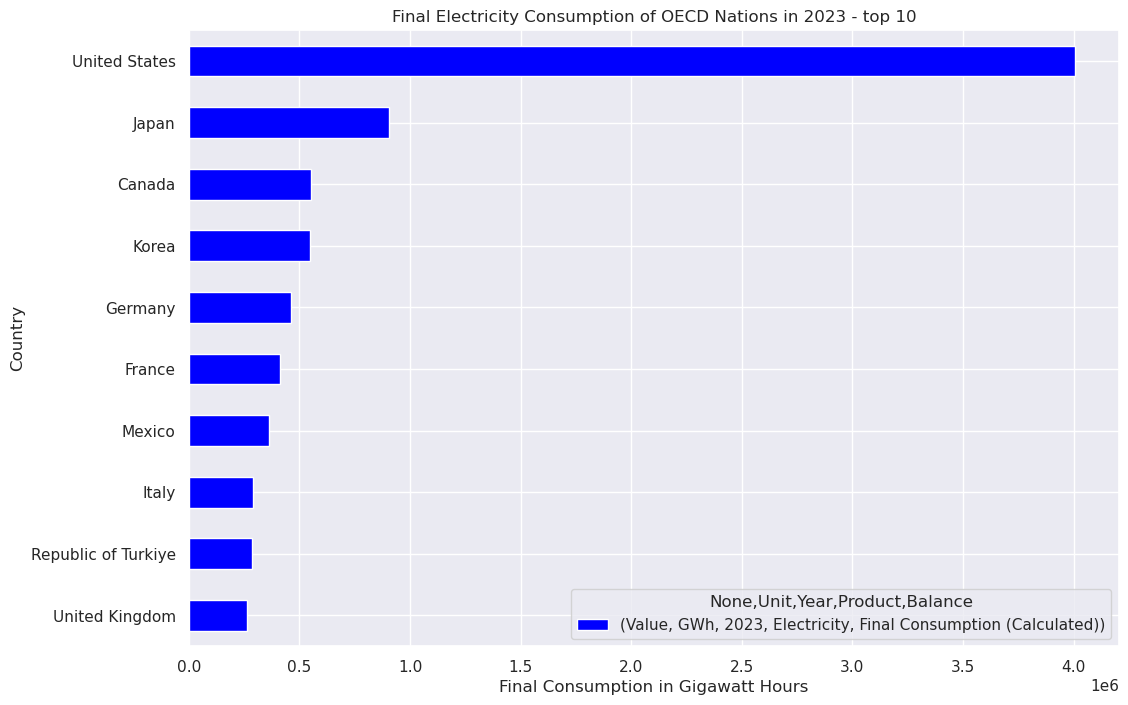

In [108]:
df_2023_consumption_unstacked = df_2023_consumption.sort_values(by = 'Value', ascending = True)
df_2023_consumption_unstacked = df_2023_consumption_unstacked.unstack().unstack()
df_2023_consumption_unstacked = df_2023_consumption_unstacked.unstack().unstack()
df_2023_consumption_unstacked.plot(
    kind = 'barh',
    figsize = [12,8],
    title = 'Final Electricity Consumption of OECD Nations in 2023 - top 10',
    color = 'blue',
    ylabel = 'Country',
    xlabel = 'Final Consumption in Gigawatt Hours'
    #yticks = df_2023_consumption['Country']
)

It is interesting to note that the Final Consumption of the USA is more than 4 times the consumption of Japan which is second.

Perhaps looking at "Electricity Production" will give us an even more comprehensive picture.

## **Question 2 Findings**

**Question 2: Which are the top 10 countries in the OECD dataset with the highest Net Electricity Production for the entirety of 2023?**

In order to answer this, we will need to filter the dataframe for 2023 and the Balance "Net Electricity Production". Then we will need to aggregate the values by country and year for Electricity Production.

Total Renewables in the dataset include Hydro, Solar, Wind,  Combustible Renewals and Other Renewables. This leaves the non-renewables including Coal, Natural Gas, Oil and Petroleum Products, Nuclear, Other Combustible Non-renewables and "Not Specified".

In [109]:
# Filtering the dataframe for 2023
df_2023 = df_monthly_elec[
    (df_monthly_elec['Time'] >= '2023-01-01') & (df_monthly_elec['Time'] <= '2023-12-31')
    ]
# Filtering the dataframe for the Balance "Net Electricity Production", the metric of interest
df_2023_production = df_2023[df_2023['Balance'] == 'Net Electricity Production']

# Similar to Question 1, checking that all months are populated across all countries
df_2023_production_check = df_2023_production[['Country', 'Time']].drop_duplicates()
df_2023_production_check['Country'].value_counts()[
    df_2023_production_check['Country'].value_counts()!=12]

Series([], Name: Country, dtype: int64)

Since the above dataframe is empty, we can be confident that there are 12 months worth of data "Net Electricity Production" data for each country.

Now we can go on to further aggregate the data to find the top 10 countries for Electricity Production.

In [110]:
#Aggregating GWh values across Country, Year, Unit and Balance 
df_2023_production = df_2023_production.groupby(
    ['Country', 'Year', 'Unit', 'Balance', 'Product']).sum('Value')
# Unstacking the Product to get the different types of energy generation - Hydro, Geo, etc.
df_2023_production = df_2023_production.unstack()
# Filling null values (ie. if a country does not have a specific form of energy generation)
df_2023_production = df_2023_production.fillna(0)

df_2023_production.columns = df_2023_production.columns.droplevel()

#Taking a look at the resulting datafame to see the new columns
display(df_2023_production.head(5))

,,,Product,"Coal, Peat and Manufactured Gases",Combustible Renewables,Electricity,Geothermal,Hydro,Natural Gas,Not Specified,Nuclear,Oil and Petroleum Products,Other Combustible Non-Renewables,Other Renewables,Solar,Total Combustible Fuels,"Total Renewables (Hydro, Geo, Solar, Wind, Other)",Wind
Country,Year,Unit,Balance,,,,,,,,,,,,,,,
Argentina,2023,GWh,Net Electricity Production,1146.6303,2162.6892,130607.8578,0.0000,21724.9408,66048.2117,0.0000,9010.5737,12940.9046,0.0000,0.0,3240.2389,82298.4360,41461.5377,14333.6684
Australia,2023,GWh,Net Electricity Production,117754.7571,3011.2949,261570.5851,0.0000,15886.1305,41261.0532,0.0000,0.0000,3863.8638,0.0000,0.0,47631.8912,165890.9690,98690.9110,32161.5947
Austria,2023,GWh,Net Electricity Production,1878.5226,4412.5085,70144.3702,0.0024,43738.0069,7149.3095,18.1261,0.0000,738.0254,733.9521,0.0,3678.4439,14912.3180,59626.4347,7797.4732
Belgium,2023,GWh,Net Electricity Production,1786.9762,3029.1185,78668.6790,0.0000,1621.8250,17092.9077,343.5564,31230.1735,81.8542,973.0983,0.0,7473.5933,22963.9548,27160.1129,15035.5762
Brazil,2023,GWh,Net Electricity Production,14777.3455,56633.8757,690334.7156,0.0000,421900.8681,31462.8134,0.0000,13675.5431,7126.8515,1679.1936,0.0,48660.3481,111680.0796,621612.9681,94417.8762


While it appears that the "Electricity" product may be the total of all the other products, it would be worth checking that the other products sum up to the same amount. We can sum up Total Renewables each of the other non-renewables to check. We can display our calculated Total across all Products against the "Electricity" product to see if these match.

In [111]:
#Summing all relevant columns to calculation total production across all products
df_2023_production['Total_Products_Production'] =\
    df_2023_production['Total Renewables (Hydro, Geo, Solar, Wind, Other)'] +\
    df_2023_production['Coal, Peat and Manufactured Gases'] +\
    df_2023_production['Natural Gas'] + df_2023_production['Oil and Petroleum Products']+\
    df_2023_production['Nuclear'] +\
    df_2023_production['Other Combustible Non-Renewables'] +\
    df_2023_production['Not Specified']
df_2023_production = df_2023_production[['Total_Products_Production', 'Electricity']]
df_2023_production = df_2023_production.sort_values(
    by = 'Total_Products_Production',
    ascending = False)
df_2023_production_top10 = df_2023_production.head(10)
print("Top 10 countries for Net Electricity Production:")
display(df_2023_production_top10)

Top 10 countries for Net Electricity Production:


,,,Product,Total_Products_Production,Electricity
Country,Year,Unit,Balance,,
People's Republic of China,2023,GWh,Net Electricity Production,9.093244e+06,9.093244e+06
United States,2023,GWh,Net Electricity Production,4.254837e+06,4.254837e+06
India,2023,GWh,Net Electricity Production,1.802213e+06,1.802213e+06
Japan,2023,GWh,Net Electricity Production,9.770560e+05,9.770560e+05
Brazil,2023,GWh,Net Electricity Production,6.903347e+05,6.903347e+05
Canada,2023,GWh,Net Electricity Production,6.097537e+05,6.097537e+05
Korea,2023,GWh,Net Electricity Production,5.735549e+05,5.735549e+05
France,2023,GWh,Net Electricity Production,5.045534e+05,5.045534e+05
Germany,2023,GWh,Net Electricity Production,4.894727e+05,4.894727e+05


It can be seen that China produced the most electricity in 2023 (9+ million Gigawatt Hours which is 9,000+ Terawatt Hours). This number is further backed by other sources (Slotta, 2024, [Statista](https://www.statista.com/statistics/302203/china-electricity-consumption/)). China is followed by the United States (which produced less than half of what China produced). 

Additionally, the "Electricity" metric for Production perfectly matches the summation of Products ("Total_Products_Production") so we can be confident that the summation is accurate. Going forward, we can confidently use the "Electricity" product as the total across all Products for "Net Electricity Production".

Let's plot the top 10 in a graph.

<Axes: title={'center': 'Total Production of Electricity from countries in OECD Dataset - top 10'}, xlabel='Net Electricity Production in Gigawatt Hours', ylabel='Country'>

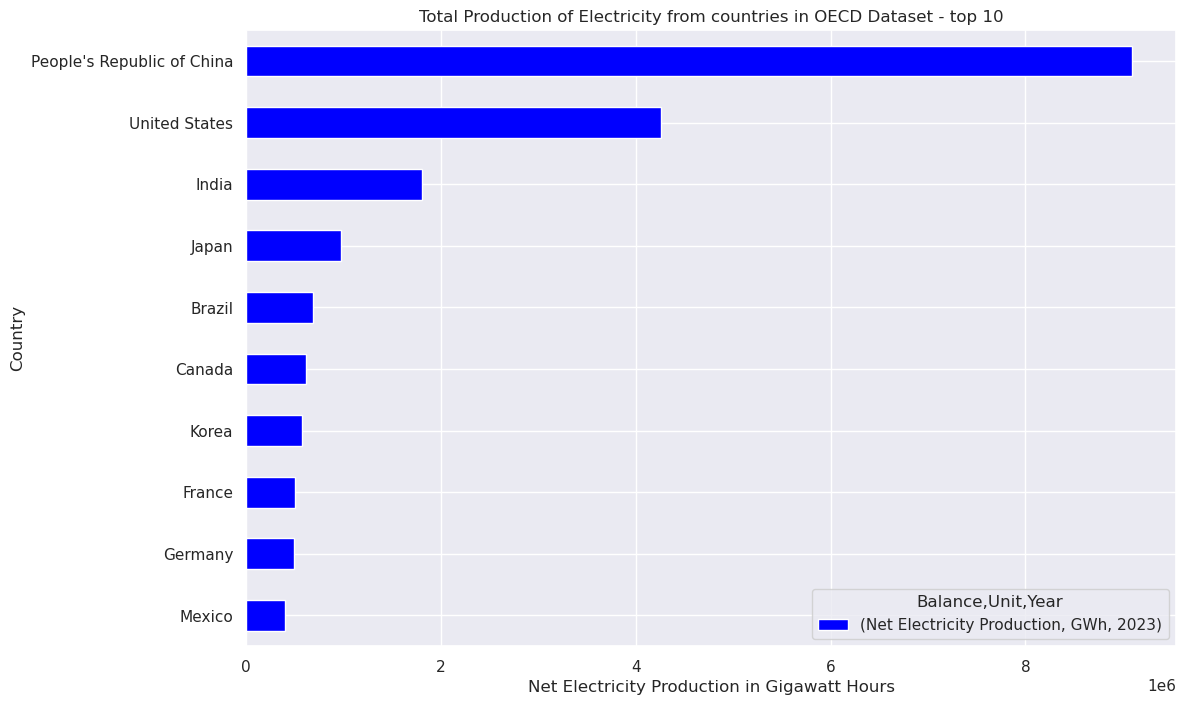

In [112]:
# Reversing sort for graph
df_2023_production_unstacked = df_2023_production_top10.sort_values(
    by='Total_Products_Production', 
    ascending = True)
# Removing extra redundant indices which do not provide any new information
df_2023_production_unstacked = df_2023_production_unstacked.unstack().unstack().unstack()

#Plotting bar graph
df_2023_production_unstacked['Total_Products_Production'].plot(
    kind = 'barh', 
    figsize = [12,8],
    title = 'Total Production of Electricity from countries in OECD Dataset - top 10',
    color = 'blue',
    ylabel = 'Country',
    xlabel = 'Net Electricity Production in Gigawatt Hours'
)

As can be seen in the graph, the top country for electricity production is the People's Republic of China, followed by the United States and India. 

While it is no surprise that China has the most electricity production, being a highly populated country with thriving industry, India's is surprisingly low in light of their population; they produced less than a quarter of China's electricity production. 

## **Question 3 Findings**

**How has the usage of different types of Products (Coal, Hydro, Solar, etc.) in electricity production varied from 2015 to 2023? Which product has the largest share of Electricity production?**

To answer this, it would be helpful to have the Total Electricity Produced by Year (Yearly), split across the different types of Products.

In [113]:
# Filtering the dataframe for 2015 to 2023
df_decade = df_monthly_elec[ # Not a whole decade but almost a decade so let's call it df_decade
    (df_monthly_elec['Time'] >= '2015-01-01') & (df_monthly_elec['Time'] <= '2023-12-31')]
# Filtering the dataframe for the Balance "Final Consumption (Calculated)", the metric of interest
df_decade_production = df_decade[df_decade['Balance'] == 'Net Electricity Production']

# Checking that all months are sufficiently populated across all countries
df_production_check = df_decade_production[['Country', 'Time']].drop_duplicates()
print(df_production_check['Country'].value_counts())

#Checking which types of products have the highest share overall
df_production_check = df_decade_production.groupby(['Balance', 'Product']).sum('Value')
df_production_check = df_production_check.sort_values(
    by = 'Value', 
    ascending = False)
display(df_production_check['Value'].to_frame())

Australia                     108
Austria                       108
Norway                        108
Poland                        108
Portugal                      108
Slovak Republic               108
Slovenia                      108
Spain                         108
Sweden                        108
Switzerland                   108
Republic of Turkiye           108
United Kingdom                108
United States                 108
Argentina                     108
Brazil                        108
Bulgaria                      108
People's Republic of China    108
Croatia                       108
Cyprus                        108
India                         108
Malta                         108
North Macedonia               108
Romania                       108
New Zealand                   108
Netherlands                   108
Mexico                        108
Luxembourg                    108
Belgium                       108
Canada                        108
Chile         

Value
Balance                    Product                                                        
Net Electricity Production Electricity                                        1.822353e+08
                           Total Combustible Fuels                            1.121255e+08
                           Coal, Peat and Manufactured Gases                  7.378678e+07
                           Total Renewables (Hydro, Geo, Solar, Wind, Other)  5.429676e+07
                           Natural Gas                                        3.105184e+07
                           Hydro                                              2.990585e+07
                           Nuclear                                            1.993501e+07
                           Wind                                               1.311881e+07
                           Solar                                              6.366291e+06
                           Combustible Renewables                             4.442362e+06
                           Oil and Petroleum Products                         2.257079e+06
                           Other Combustible Non-Renewables                   5.881419e+05
                           Geothermal                                         4.544836e+05
                           Not Specified                                      3.204529e+05
                           Other Renewables                                   8.967178e+03

Knowing all 108 months from 2015 to 2023 are sufficiently populated (except for Costa Rica which we can remove), we can go ahead and create a plot of the usage of different products over time.

It can also be seen that Coal, Natural Gas, Hydro, Nuclear, Wind, and Solar have the largest shares overall, so we can group the other products which have a smaller share.

<Axes: title={'center': 'Types of Energy Generation from 2015 to 2023'}, xlabel='Year', ylabel='Total GWh'>

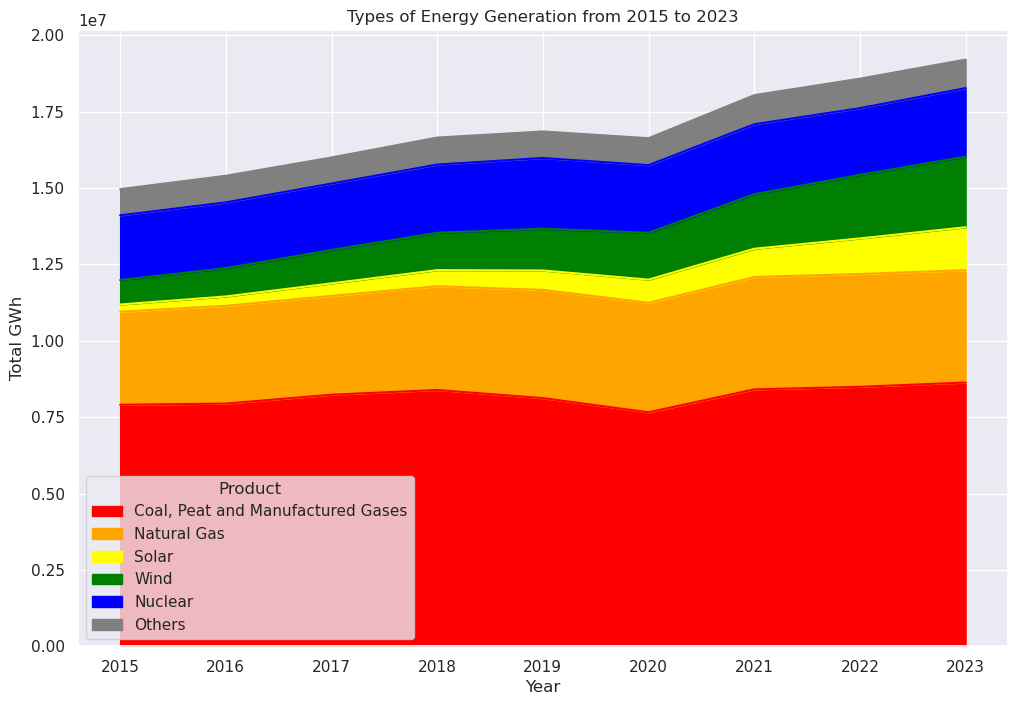

In [114]:
# Removing Costa Rica since it is not populated across all months/years
df_decade_production = df_decade_production[
    df_decade_production['Country']!= 'Costa Rica'
]

#Aggregating GWh values across Country, Year, Unit and Balance 
df_decade_production = df_decade_production.groupby(
    ['Year', 'Unit', 'Balance', 'Product']).sum('Value')

# Unstacking the Product to get the different types of energy generation - Hydro, Geo, etc.
df_decade_production = df_decade_production.unstack()
# Filling null values (ie. if a country does not have a specific form of energy generation)
df_decade_production = df_decade_production.fillna(0)

df_decade_production.columns = df_decade_production.columns.droplevel()

# We only want to look at the main types of energy generation, and group the smaller ones
df_decade_production['Major_energy_sources'] =\
    df_decade_production['Coal, Peat and Manufactured Gases'] +\
    df_decade_production['Natural Gas'] +\
    df_decade_production['Hydro'] +\
    df_decade_production['Solar'] +\
    df_decade_production['Wind']+\
    df_decade_production['Nuclear']

df_decade_production['Others'] = df_decade_production['Electricity'] -\
    df_decade_production['Major_energy_sources'] 

#Taking only relevant columns for plotting
df_decade_production_selected = df_decade_production[
    ['Coal, Peat and Manufactured Gases',
    'Natural Gas',
    'Solar',
    'Wind',
    'Nuclear',
    'Others'
    ]
]

df_decade_production_selected.index = df_decade_production_selected.index.droplevel(2)
df_decade_production_selected.index = df_decade_production_selected.index.droplevel(1)


df_decade_production_selected.plot(
    kind = 'area',
    figsize = [12,8],
    color = {
        "Coal, Peat and Manufactured Gases":"red", 
        "Natural Gas":"orange",
        "Solar":"yellow",
        "Wind":"green",
        "Nuclear":"blue", 
        "Others" :"grey"},
    title = 'Types of Energy Generation from 2015 to 2023',
    ylabel = 'Total GWh'
)

It can be seen from the above plot that while all the major products used in electricity generation have continued to be used since 2015, Coal, Peat and Manufactured Gases has the largest share of electricity generation. 

It is owrth noting that amount of Solar and Wind generation have been increasing over time.

## **Question 4 Findings**

**How has the share of renewables in electricity production varied from 2015 to 2023 for Australia? How does this trend look for other countries in the OECD dataset?**

In order to answer this, we can use a dataframe previously created.

<Axes: title={'center': 'All countries in dataset - Renewable versus Non-renewable generation over time'}, xlabel='Year', ylabel='Share'>

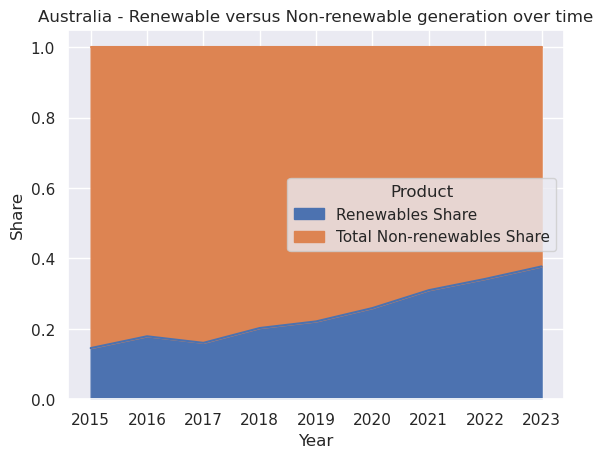

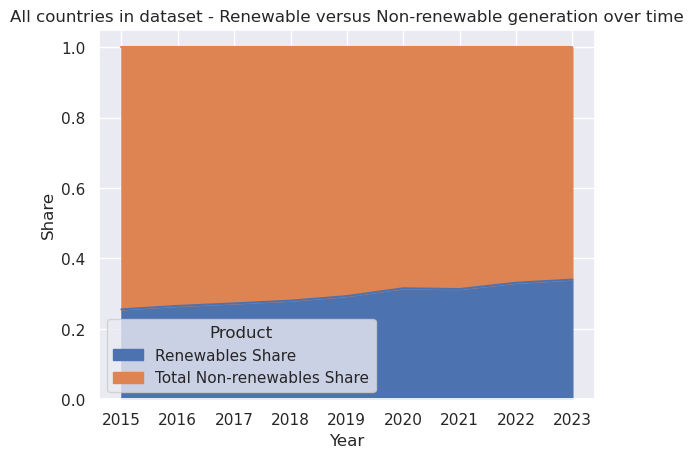

In [115]:
# Filtering the dataframe for 2015 to 2023
df_decade = df_monthly_elec[
    (df_monthly_elec['Time'] >= '2015-01-01') & (df_monthly_elec['Time'] <= '2023-12-31')]
# Filtering the dataframe for the Balance "Net Electricity Production", the metric of interest
df_decade_production = df_decade[df_decade['Balance'] == 'Net Electricity Production']

# For Australia specifically
df_decade_production_Aus = df_decade_production[
    df_decade_production['Country'] == 'Australia']
df_decade_production_Aus = df_decade_production_Aus.groupby(
    ['Year', 'Unit', 'Balance', 'Product']).sum('Value')
# Unstacking the Product to get the different types of energy generation - Hydro, Geo, etc.
df_decade_production_Aus = df_decade_production_Aus.unstack()

#Turning nulls into 0
df_decade_production_Aus = df_decade_production_Aus.fillna(0)

df_decade_production_Aus.columns = df_decade_production_Aus.columns.droplevel()

# Calculating Total Non-renewables
df_decade_production_Aus['Total Non-renewables'] =\
    df_decade_production_Aus['Electricity'] -\
    df_decade_production_Aus['Total Renewables (Hydro, Geo, Solar, Wind, Other)']

# Calculating the share of Total Electricity Production
df_decade_production_Aus['Total Non-renewables Share'] =\
    df_decade_production_Aus['Total Non-renewables']/df_decade_production_Aus['Electricity']
df_decade_production_Aus['Renewables Share'] =\
    df_decade_production_Aus['Total Renewables (Hydro, Geo, Solar, Wind, Other)']/\
    df_decade_production_Aus['Electricity']

df_decade_production_Aus.index = df_decade_production_Aus.index.droplevel(2)
df_decade_production_Aus.index = df_decade_production_Aus.index.droplevel(1)

df_decade_production_Aus[['Renewables Share','Total Non-renewables Share']].plot(
    kind = 'area', 
    ylabel = 'Share',
    title = 'Australia - Renewable versus Non-renewable generation over time'
)

#For the total across countries, aggregating GWh values across Year, Unit and Balance and Produt
df_decade_production = df_decade_production.groupby(
    ['Year', 'Unit', 'Balance', 'Product']).sum('Value')
# Unstacking the Product to get the different types of energy generation - Hydro, Geo, etc.
df_decade_production = df_decade_production.unstack()
# Filling null values (ie. if a country does not have a specific form of energy generation)
df_decade_production = df_decade_production.fillna(0)
df_decade_production.columns = df_decade_production.columns.droplevel()
df_decade_production['Total Non-renewables'] =\
    df_decade_production['Electricity'] -\
    df_decade_production['Total Renewables (Hydro, Geo, Solar, Wind, Other)']

# Calculating the share of Total Electricity Production
df_decade_production['Total Non-renewables Share'] =\
    df_decade_production['Total Non-renewables']/df_decade_production['Electricity']
df_decade_production['Renewables Share'] =\
    df_decade_production['Total Renewables (Hydro, Geo, Solar, Wind, Other)']/\
    df_decade_production['Electricity']

df_decade_production.index = df_decade_production.index.droplevel(2)
df_decade_production.index = df_decade_production.index.droplevel(1)

df_decade_production[['Renewables Share','Total Non-renewables Share']].plot(
    kind = 'area', 
    ylabel = 'Share',
    title = 'All countries in dataset - Renewable versus Non-renewable generation over time'
)

While the share of Renewables in electricity production has been steadily increasing for the full set of countries in the dataset, it has been increasing at a slightly higher rate for Australia since around 2017. 

## **Question 5 Findings**

**How does the electricity production relate to the population of the country for 2023?**

In order to answer this question, we will need to use the 2023 population dataset, as well as the previously created dataframe with electricity production in 2023.

In [116]:
# Taking previously created dataframe from Question 2 with Electricity Production
df_2023_production.index = df_2023_production.index.droplevel(3)
df_2023_production.index = df_2023_production.index.droplevel(2)
df_2023_production.index = df_2023_production.index.droplevel(1)
df_2023_production.reset_index().head(5)

Product,Country,Total_Products_Production,Electricity
0,People's Republic of China,9.093244e+06,9.093244e+06
1,United States,4.254837e+06,4.254837e+06
2,India,1.802213e+06,1.802213e+06
3,Japan,9.770560e+05,9.770560e+05
4,Brazil,6.903347e+05,6.903347e+05


In [117]:
# Checking if population dataframe can be merged with electricity dataframe based on 'Country'
df_merge_check = df_world_pop.merge(
    df_2023_production, 
    how = 'right', 
    left_on = 'Country', 
    right_on = 'Country')
df_merge_check[df_merge_check['Population2023'].isnull()]

,Country,Population2023,Total_Products_Production,Electricity
0,People's Republic of China,NaN,9.093244e+06,9.093244e+06
6,Korea,NaN,5.735549e+05,5.735549e+05
10,Republic of Turkiye,NaN,3.105330e+05,3.105330e+05
25,Czech Republic,NaN,7.050436e+04,7.050436e+04
36,Slovak Republic,NaN,2.740739e+04,2.740739e+04


In [118]:
# Fix countries in population dataset with mismatched names
df_world_pop['Country_updated'] = df_world_pop['Country']

df_world_pop['Country_updated'] = where(
    df_world_pop['Country']=='China', 
    'People\'s Republic of China', 
    df_world_pop['Country_updated'])
df_world_pop['Country_updated'] = where(
    df_world_pop['Country']=='South Korea', 
    'Korea', 
    df_world_pop['Country_updated'])
df_world_pop['Country_updated'] = where(
    df_world_pop['Country']=='Turkey', 
    'Republic of Turkiye', 
    df_world_pop['Country_updated'])
df_world_pop['Country_updated'] = where(
    df_world_pop['Country']=='Czech Republic (Czechia)', 
    'Czech Republic', 
    df_world_pop['Country_updated'])
df_world_pop['Country_updated'] = where(
    df_world_pop['Country']=='Slovakia', 
    'Slovak Republic', 
    df_world_pop['Country_updated'])

In [119]:
#Checking that mismatches have been fixed correctly
df_merge_check = df_world_pop.merge(
    df_2023_production, 
    how = 'right', 
    left_on = 'Country_updated', 
    right_on = 'Country')
df_merge_check[df_merge_check['Population2023'].isnull()]

,Country,Population2023,Country_updated,Total_Products_Production,Electricity


There are no more mismatched country names so we can go ahead and merge our datasets. 

Text(33.0, 0.5, 'Electricity produced in 2023')

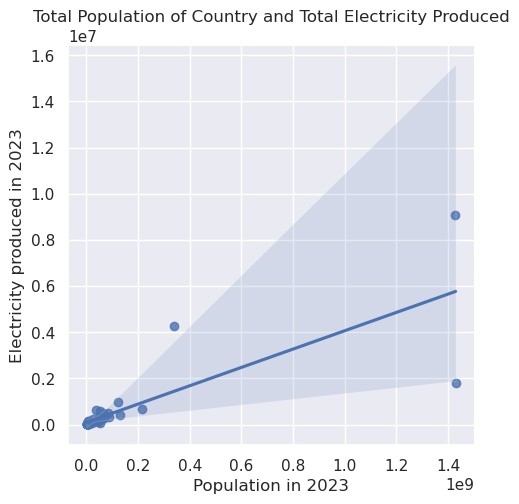

In [120]:
#Merging electricity data with population data
df_pop_elec_merged = df_world_pop.merge(
    df_2023_production, 
    how = 'right', 
    left_on = 'Country_updated', 
    right_on = 'Country')

# Using Seaborn for plotting
sns.set()
sns.lmplot(
    data = df_pop_elec_merged,
    x = 'Population2023',
    y = 'Electricity',
    fit_reg = True
)

plt.title('Total Population of Country and Total Electricity Produced')
# Set x-axis label
plt.xlabel('Population in 2023')
# Set y-axis label
plt.ylabel('Electricity produced in 2023')


It can be seen that there is a general trend present. Countries with larger populations tend to produce larger amounts of electricity. India is potentially an outlier for this rule, as their electricity production is lower than expected for their population (ie. noticeably below the regression line on the right.)

It can be seen that there are a cluster of small countries on the bottom left of the plot. If the larger countries were removed, these ones could be seen more clearly.

Text(33.0, 0.5, 'Electricity produced in 2023')

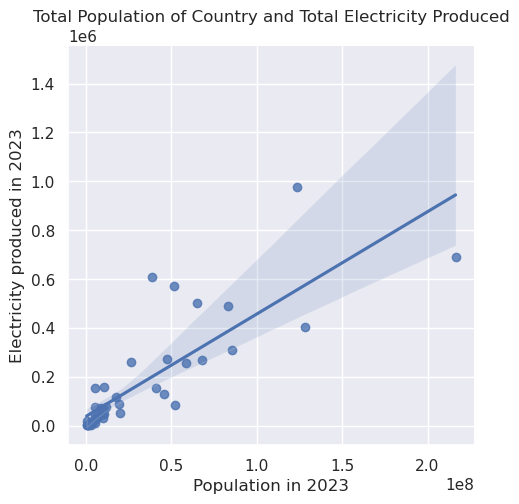

In [121]:
df_pop_elec_merged_ex_India = df_pop_elec_merged[
    ~(df_pop_elec_merged['Country_updated']=='India')&
    ~(df_pop_elec_merged['Country_updated']=='People\'s Republic of China') &
    ~(df_pop_elec_merged['Country_updated']=='United States')
]

sns.set()
sns.lmplot(
    data = df_pop_elec_merged_ex_India,
    x = 'Population2023',
    y = 'Electricity',
    fit_reg = True
)

plt.title('Total Population of Country and Total Electricity Produced')
# Set x-axis label
plt.xlabel('Population in 2023')
# Set y-axis label
plt.ylabel('Electricity produced in 2023')

The trend still appears to hold at a high level, though there is not an obvious linear relationship.

## **Question 6 Findings**

**Which country has the highest "per person" production for 2023?**

In [122]:
#Calculating electricity production per person.
df_pop_elec_merged['per_person_elec_production'] =\
    df_pop_elec_merged['Electricity']/ df_pop_elec_merged['Population2023'] * 1000 # convert to MWh

#Sorting from highest to lowest
df_pop_elec_merged = df_pop_elec_merged[['Country_updated', 'per_person_elec_production']].sort_values(
    by = 'per_person_elec_production', 
    ascending = False)
    
display(df_pop_elec_merged.head(5))

,Country_updated,per_person_elec_production
37,Iceland,52.870579
16,Norway,28.141637
5,Canada,15.722883
15,Sweden,15.159953
23,Finland,14.084772


It appears that Iceland is the largest energy producer per capita. Though this is surprising to find in the dataset, it appears to align with a government source (Government of Iceland, 2024, [link](https://www.government.is/topics/business-and-industry/energy/)) which mentions that Iceland is the "largest electricity producer per capita". 

## **Question 7 Findings**

**How does the total electricity production vary over the course of a year in terms of yearly seasonality?**

Similar to previous questions, let's start by filtering the dataframe and aggregating for the data required.

<Axes: title={'center': 'Yearly Seasonality of Total Electricity Production'}, xlabel='Month'>

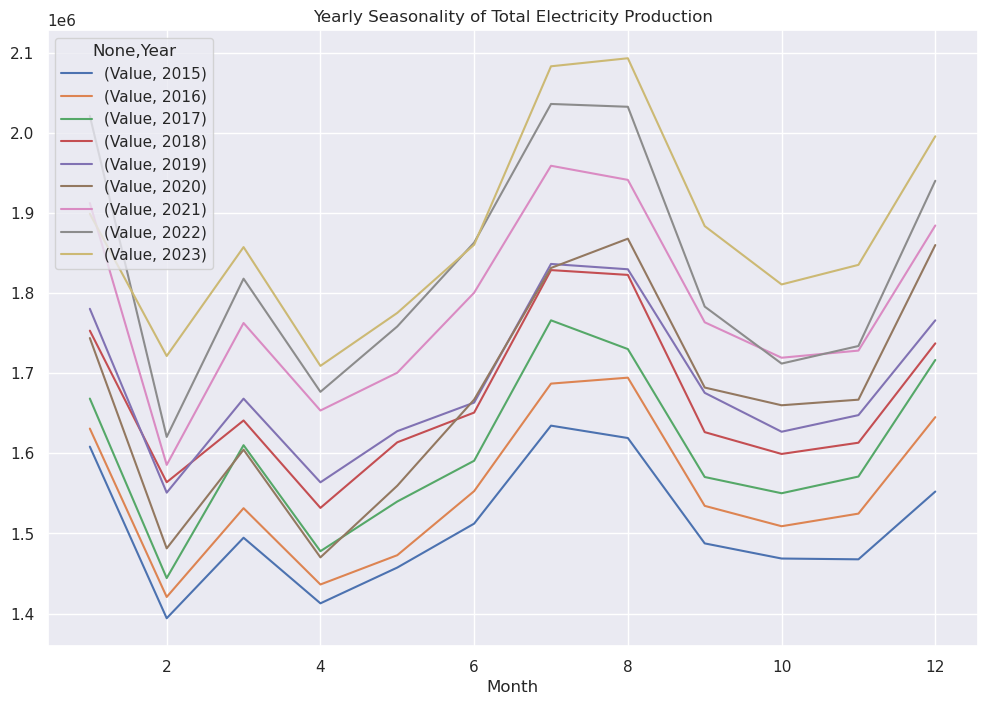

In [123]:
# Filtering the dataframe for 2015 to 2023
df_decade = df_monthly_elec[
    (df_monthly_elec['Time'] >= '2015-01-01') & (df_monthly_elec['Time'] <= '2023-12-31')]
# Filtering the dataframe for the Balance "Net Electricity Production)", the metric of interest
df_decade_production = df_decade[df_decade['Balance'] == 'Net Electricity Production']

# Filtering the dataframe for the Product "Electricity", the total across all products
df_decade_production = df_decade_production[df_decade_production['Product'] == 'Electricity']
df_decade_production['Month'] = df_decade_production['Time'].dt.month

#Grouping and unstacking by 'year' specifically to show yearly seasonality across multiple years
df_decade_production = df_decade_production.groupby(['Month', 'Balance', 'Year']).sum('Value')
df_decade_production = df_decade_production.unstack()
df_decade_production.index = df_decade_production.index.droplevel(1)
df_decade_production.plot(
    kind = 'line',
    figsize = [12,8],
    title = 'Yearly Seasonality of Total Electricity Production'
)


It can be seen that, while each year, the electricity production has been increasing, the yearly seasonal trend is very similar. The electricity production tends to be higher around July/August and then higher around December/January.

## **Question 8 Findings**

**How does the electricity production of Australia vary over the course of a year?**

This is exactly the same as the previous question but for Australia only.

/tmp/ipykernel_29/4085501840.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_decade_production_Aus['Month'] = df_decade_production['Time'].dt.month


<Axes: title={'center': "Yearly Seasonality of Australia's Electricity Production"}, xlabel='Month'>

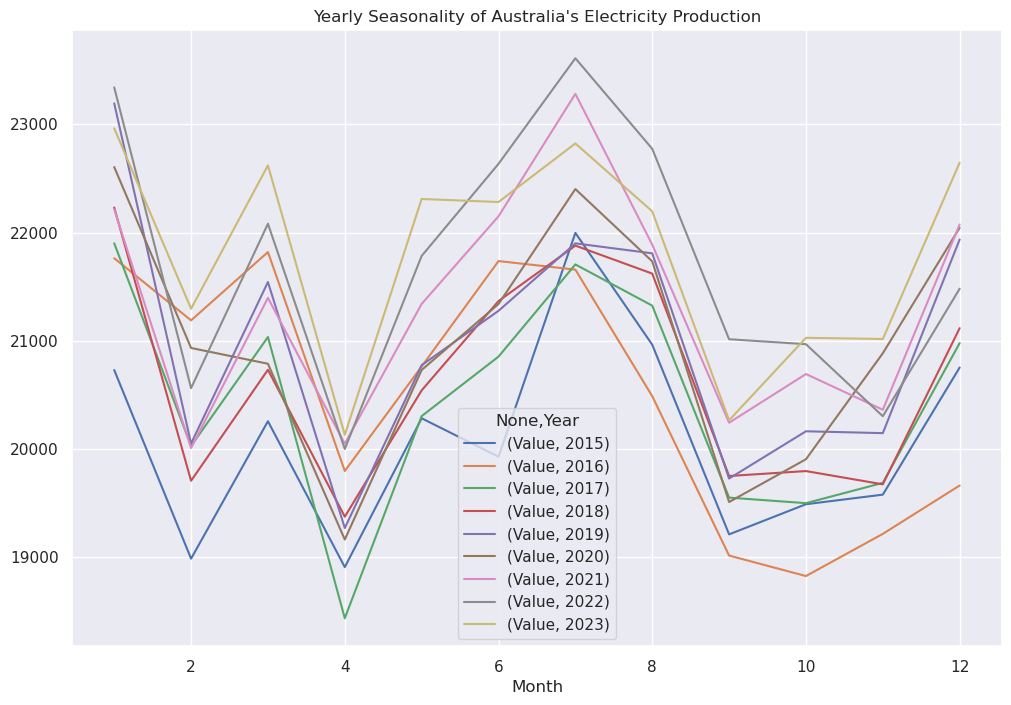

In [124]:
# Using previously created dataframe - df_decade
df_decade_production = df_decade[df_decade['Balance'] == 'Net Electricity Production']

# Filtering the dataframe for the Product "Electricity", the total across all products
df_decade_production = df_decade_production[df_decade_production['Product'] == 'Electricity']

#Filtering for Australia only
df_decade_production_Aus = df_decade_production[df_decade_production['Country'] == 'Australia']

#Aggregating data, and unstacking by year to show different years with different lines
df_decade_production_Aus['Month'] = df_decade_production['Time'].dt.month
df_decade_production_Aus = df_decade_production_Aus.groupby(['Month', 'Balance', 'Year']).sum('Value')
df_decade_production_Aus = df_decade_production_Aus.unstack()
df_decade_production_Aus.index = df_decade_production_Aus.index.droplevel(1)
df_decade_production_Aus.plot(
    kind = 'line',
    figsize = [12,8],
    title = 'Yearly Seasonality of Australia\'s Electricity Production'
)

Similar to the other countries, Australia exhibits yearly seasonality in electricity production, with higher production during July, and another peak during December/January. 

## **Question 9 Findings**

**Which countries produced the most CO2 per capita in 2019 (latest available year)?**

For this question, we will use the carbon emissions dataset. As we have the carbon emissions and population data across most countries globally, this is a great opportunity to use a global heat map to show emissions per capita. 

In [125]:
# Filtering carbon emissions dataset for 2019
df_carbon_emissions = df_carbon_emissions[df_carbon_emissions['year'] == 2019]

/tmp/ipykernel_29/2522868395.py:2: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = geopandas.read_file(geopandas.datasets.get_path('naturalearth_lowres'))


<Axes: title={'center': 'Emissions per Capita by Country'}>

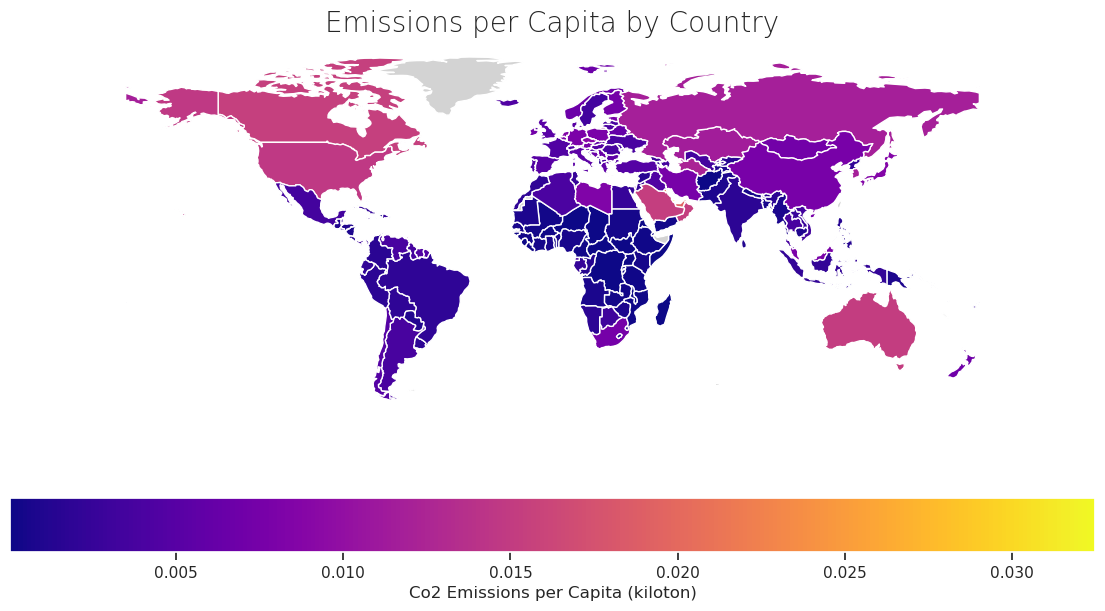

In [129]:
# To display the global heat map, load the world map data file
world = geopandas.read_file(geopandas.datasets.get_path('naturalearth_lowres'))
world = world[(world.name!="Antarctica")]
world.rename({'iso_a3': 'country_code'}, axis=1, inplace=True)

# Fix some incorrect country codes that were discovered from missing data
world['country_code'] = where(world['name']=='France', 'FRA', world['country_code'])
world['country_code'] = where(world['name']=='Norway', 'NOR', world['country_code'])

# Merge with our data 
world = world.merge(df_carbon_emissions, on=['country_code'], how='left')

# Divide by population for "per capita" numbers
world['emissions_per_capita'] = world['value']/world['pop_est']

# Create the heatmap
fig, ax_world = plt.subplots(1, figsize=(14, 7))
ax_world.set_title(
    'Emissions per Capita by Country', 
    fontdict={'fontsize': '20', 'fontweight': '50'}
)
ax_world.axis('off')
world.plot(
    column='emissions_per_capita', 
    legend=True,
    ax=ax_world,
    cmap='plasma',
    missing_kwds={"color": "lightgrey"},
    legend_kwds = {"label":"Co2 Emissions per Capita (kiloton)", "orientation":"horizontal"}
)

In [127]:
# Now let's list the top 10 countries for emissions per capita
world1 = world[['country_code', 'country_name', 'year', 'emissions_per_capita']]
world1.sort_values(
    by = 'emissions_per_capita', ascending = False).head(10)

,country_code,country_name,year,emissions_per_capita
85,QAT,Qatar,2019.0,0.032475
86,KWT,Kuwait,2019.0,0.022022
84,ARE,United Arab Emirates,2019.0,0.019330
149,BRN,Brunei Darussalam,2019.0,0.016133
3,CAN,Canada,2019.0,0.015436
128,LUX,Luxembourg,2019.0,0.015309
158,SAU,Saudi Arabia,2019.0,0.015285
88,OMN,Oman,2019.0,0.015282
137,AUS,Australia,2019.0,0.015239
4,USA,United States,2019.0,0.014677


It looks like Qatar had the highest emissions per capita based on the data that we used. This appears to agree with this finding by Lu, M. (2023, [link](https://www.visualcapitalist.com/ranked-per-capita-carbon-emissions-by-country/#:~:text=Which%20Country%20Has%20the%20Highest,peers%20in%20the%20top%20ranks.)) which states that "Qatar, ranked first, produced nearly 36 tonnes of CO₂ per resident in the country in 2021, well ahead of its peers in the top ranks." Since we are looking at 2019, 0.032 kilotons seems reasonable.

## **Question 10 Findings**

**Looking a individual countries, How does the amount of combustible fuels used in electricity production relate to CO2 emissions in 2019?**

For this question it would be great to combine the electicity production dataset with the CO2 dataset, to show a scatter plot.

We will specifically need to look at "combustible fuels" based production in the electricity production dataset. Note that "combustible fuels" include products such as coal, natural gas, and oil (IEA, 2021).

Text(47.625, 0.5, 'CO2 Emissions for Country')

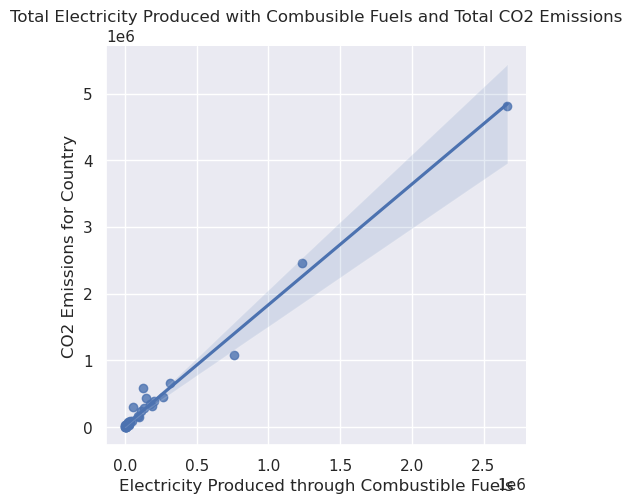

In [130]:
# Filtering the dataframe for 2023

df_2019 = df_monthly_elec[
    (df_monthly_elec['Time'] >= '2019-01-01') & (df_monthly_elec['Time'] <= '2019-12-31')
    ]

# Filtering the dataframe for the Balance "Net Electricity Production", the metric of interest
df_2019_production = df_2019[df_2019['Balance'] == 'Net Electricity Production']
# Specifically filtering for "combustible fuels"
df_2019_production = df_2019[df_2019['Product'] == 'Total Combustible Fuels']

#Aggregating GWh values across Country, Year, Unit, Balance and Product
df_2019_production = df_2019_production.groupby(
    ['Country', 'Year', 'Unit', 'Balance', 'Product']).sum('Value')
df_2019_production.index = df_2019_production.index.droplevel(4)
df_2019_production.index = df_2019_production.index.droplevel(3)
df_2019_production.index = df_2019_production.index.droplevel(2)
df_2019_production.index = df_2019_production.index.droplevel(1)
df_2019_production = df_2019_production.reset_index()

#Merging datasets
df_elec_co2_merged = df_2019_production.merge(
    world, how = 'left', 
    left_on = 'Country', 
    right_on = 'country_name')

sns.set()
sns.lmplot(
    data = df_elec_co2_merged,
    x = 'Value',
    y = 'value',
    fit_reg = True
)

plt.title('Total Electricity Produced with Combusible Fuels and Total CO2 Emissions')
# Set x-axis label
plt.xlabel('Electricity Produced through Combustible Fuels')
# Set y-axis label
plt.ylabel('CO2 Emissions for Country')

It is clear that there is a strong relationship between the amount of Combustible Fuels used in Electricity Production and the overall CO2 emissions. 
Visually speaking, the points seem quite close to the regression line. 

# 4. Summary of Findings

**Overall Production and Consumption**

The top 3 countries with the highest electricity production include China, USA and India which have the highest populations globally. In terms of Final Electricity Consumption, as this metric was missing for China and India, the top countries in our dataset were the USA followed by Japan. (Question 1 and 2)

There appears to be a reasonable association between population and total electricity production, especially in terms of direction (ie. countries with higher populations tend to produce more electricity), however the strength of the relationship is moderate (ie. the points are not extremely close to the regression line shown in Question 5).

Iceland has the highest Electricity Production per capita (Question 6). 

**Products used in Electricity Generation**

Coal (and coal products) have the highest share of all the products used in Electricity Production. This has been since 2015 and is still the current state. Natural Gas is the second most utilised product for Electricity generation. The share of renewables in Electricity Production (eg. Solar, Hydro, Wind) have been steadily increasing over time (as per the data from 2015 to 2023) - both in Australia and the set of 48 countries in the OECD dataset. (Question 3 and Question 4)

**Yearly Seasonality of Electricity Production**

With the countries in the OECD dataset, there was obvious yearly seasonality in electricity production with the peak months being July/August and December/January. This trend was very similar for Australia alone, exluding August. The overall electricity production has been increasing year by year. (Question 7 and 8)

**CO2 Emissions**

There is a strong correlation between the amount of combustible fuels used in Electricity Production and the overall CO2 emissions (on a per-country basis). The country with the highest CO2 emissions per Capita in 2019 is Qatar, followed by Kuwait. (Question 9 and 10)


# 5. Recommendations and Conclusion

In light of the above, it is clear that electricity production and consumption levels have been rising over time, and it is likely that they will continue to rise in the years going forward. 

If the use of Combustible Fuels continues to increase, CO2 emissions will likely increase as well. Therefore, it is a good sign that the portion of electricity generated from renewable sources has been increasing over time.

In light of the above findings, it is worth looking further into whether global electricity production/consumption at current rates can be sustained going forward. This may involve looking into questions such as:
* How much Coal, Natural Gas and non-renewable resources are still available, as per current knowledge? Can we forecast their availability over the coming decades?
* What is the cost of running existing powerplants across the different energy sources?
* How many powerplants/generators are approaching their 'end of life'?
* What is the cost of establishing new wind farms, solar farms, hydroelectric generators and etc.?
* How does the rate of development in electricity generation (eg. building new generators) compare to the rates of population increase?

As a final note, considering all of the above, it would be valuable to further research and understand sustainable forms of electricity storage.

# 6. References

* United Nations, 2023, *The Sustainable Development Goals Report*, accessed 22 April 2024, available at:https://unstats.un.org/sdgs/report/2023/The-Sustainable-Development-Goals-Report-2023.pdf
* IEA, 2024, Monthly Electricity Statistics, IEA, Paris, accessed 20 April 2024, available at: https://www.iea.org/data-and-statistics/data-product/monthly-electricity-statistics
* Arvidsson, J. 2023, *World Population by Country 2023*, Kaggle, accessed 20 April 2024, available at: https://www.kaggle.com/datasets/joebeachcapital/world-population-by-country-2023world-population-by-country-2023
* Pedersen, U. 2023, *CO2 Emissions*, Kaggle, accessed 20 April 2024, available at: https://www.kaggle.com/datasets/ulrikthygepedersen/co2-emissions-by-country
* Collins, P. 2023, *Carbon negative country: How can it be achieved?*, Climate Consulting by Selectra, accessed 20 April 2024, available at: https://climate.selectra.com/en/carbon-footprint/carbon-negative-country 
* Government of Iceland, 2024, *Energy*, Government of Iceland, accessed 20 April 2024, available at: https://www.government.is/topics/business-and-industry/energy/
* Slotta, D. 2024, *Power consumption in China 2010 to 2023, Statista*, Statista, accessed 20 April 2024, available at: https://www.statista.com/statistics/302203/china-electricity-consumption/
* Lu, M. 2023, Ranked: *Per Capita Carbon Emissions by Country*, Visual Captalist, accessed 20 April 2024, available at: https://www.visualcapitalist.com/ranked-per-capita-carbon-emissions-by-country/.
* IEA, 2021, *Electricity Production*, IEA, Paris, accessed 20 April 2024, available at: https://www.iea.org/reports/electricity-information-overview/electricity-production, Licence: CC BY 4.0
* GeoPandas developers (2023). Plotting with Geoplot and GeoPandas — GeoPandas 0.8.0
documentation. geopandas.org., accessed 19 April 2024, Available at:
https://geopandas.org/gallery/plotting_with_geoplot.html
(https://geopandas.org/gallery/plotting_with_geoplot.html)
* UNSW, UNSW Course Notes, Principles of Programming, UNSW Moodle